# 📊  Análisis de Datos viviendas en Estados Unidos

---

**Autor:** Jesus Gustavo Camacho Olivos  
**Año de venta:** Abril 2026  
**Versión:** 1.0  

---

## 📌 1. Introducción del Proyecto

### 🎯 Objetivos del Análisis

1. **Objetivo Principal:** Identificar los factores clave que impactan en [variable objetivo]
2. **Objetivos Específicos:**
   - Analizar la distribución y tendencias de las variables principales
   - Detectar patrones estacionales o temporales
   - Identificar segmentos de alto y bajo rendimiento
   - Proponer recomendaciones basadas en datos

---

### ❓ Preguntas Clave a Responder

- ¿Cuáles son las tendencias principales en los datos?
- ¿Existen correlaciones significativas entre variables?
- ¿Qué segmentos o categorías tienen mejor desempeño?
- ¿Hay valores atípicos o anomalías que requieran atención?
- ¿Qué factores predicen mejor la variable objetivo?

---

## 📦 2. Importación de Librerías

Configuramos el entorno de trabajo con las librerías necesarias para el análisis.

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Estadística y análisis
from scipy import stats
from scipy.stats import normaltest, skew, kurtosis

# Utilidades
import warnings
from datetime import datetime, timedelta
import os

# Configuraciones generales
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas correctamente")
print(f"📌 Pandas version: {pd.__version__}")
print(f"📌 NumPy version: {np.__version__}")

✅ Librerías importadas correctamente
📌 Pandas version: 3.0.2
📌 NumPy version: 2.4.4


## 📥 3. Carga de Datos

### 📂 Opciones de Carga de Datos

A continuación se presentan diferentes métodos para cargar datos según la fuente.

In [2]:
# Cargar desde archivo CSV
# Archivo por defecto para el analisis principal
ruta_datos = 'train.csv'

try:
    df = pd.read_csv(ruta_datos, encoding='utf-8')
    print("✅ Datos cargados exitosamente")
    print(
        f"📊 Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(
        f"💾 Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo en '{ruta_datos}'")
    print("💡 Sugerencia: Verifica la ruta o coloca el archivo train.csv en el mismo directorio del notebook")
except Exception as e:
    print(f"❌ Error al cargar datos: {e}")

✅ Datos cargados exitosamente
📊 Dimensiones del dataset: 1,460 filas x 81 columnas
💾 Tamaño en memoria: 3.43 MB


### 👀 Vista Preliminar de los Datos

In [3]:
# Primeras filas
print("🔍 Primeras 5 filas del dataset:\n")
display(df.head())

print("\n" + "="*80 + "\n")

# Últimas filas
print("🔍 Últimas 5 filas del dataset:\n")
display(df.tail())

🔍 Primeras 5 filas del dataset:



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.00,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.00,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000




🔍 Últimas 5 filas del dataset:



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.00,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.00,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.00,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.00,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.00,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.00,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.00,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.00,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.00,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.00,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.00,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.00,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.00,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [4]:
# Información general del dataset
print("📋 Información General del Dataset:\n")
df.info()

print("\n" + "="*80 + "\n")

# Muestra aleatoria
print("🎲 Muestra aleatoria de 5 registros:\n")
display(df.sample(5))

📋 Información General del Dataset:

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-nul

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1435,1436,20,RL,80.00,8400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,9,1962,2005,Gable,CompShg,Wd Sdng,Wd Sdng,BrkFace,237.00,Gd,Gd,CBlock,TA,TA,No,Unf,0,Unf,0,1319,1319,GasA,TA,Y,SBrkr,1537,0,0,1537,1,0,1,1,3,1,Gd,7,Typ,1,Gd,Attchd,1962.00,RFn,2,462,TA,TA,Y,0,36,0,0,0,0,NaN,GdPrv,NaN,0,7,2008,COD,Abnorml,174000
17,18,90,RL,72.00,10791,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,Duplex,1Story,4,5,1967,1967,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,Slab,NaN,NaN,NaN,NaN,0,NaN,0,0,0,GasA,TA,Y,SBrkr,1296,0,0,1296,0,0,2,0,2,2,TA,6,Typ,0,NaN,CarPort,1967.00,Unf,2,516,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
832,833,60,RL,44.00,9548,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,6,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,223.00,Gd,TA,PConc,Gd,TA,No,GLQ,483,Unf,0,458,941,GasA,Ex,Y,SBrkr,941,888,0,1829,1,0,2,1,3,1,Gd,7,Typ,1,TA,Attchd,2003.00,RFn,2,613,TA,TA,Y,192,39,0,0,0,0,NaN,NaN,NaN,0,1,2010,WD,Normal,237000
224,225,20,RL,103.00,13472,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,10,5,2003,2003,Hip,CompShg,VinylSd,VinylSd,BrkFace,922.00,Ex,TA,PConc,Ex,TA,Gd,GLQ,56,Unf,0,2336,2392,GasA,Ex,Y,SBrkr,2392,0,0,2392,0,0,2,0,3,1,Ex,8,Typ,1,Ex,Attchd,2003.00,Fin,3,968,TA,TA,Y,248,105,0,0,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal,386250
1075,1076,70,RL,75.00,13125,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,6,1940,1984,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.00,TA,TA,CBlock,TA,TA,No,BLQ,410,Unf,0,390,800,GasA,TA,Y,SBrkr,960,780,0,1740,0,0,1,1,3,1,TA,6,Typ,2,Gd,Attchd,1940.00,Unf,1,240,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,7,2007,CWD,Normal,219500


## 🧹 4. Limpieza y Preparación de Datos

### 🔍 Análisis de Calidad de Datos

In [5]:
# Resumen de calidad de datos
def analizar_calidad_datos(df):
    """
    Genera un reporte completo de la calidad de los datos
    """
    calidad = pd.DataFrame({
        'Tipo_Dato': df.dtypes,
        'Valores_Nulos': df.isnull().sum(),
        '%_Nulos': (df.isnull().sum() / len(df)) * 100,
        'Valores_Únicos': df.nunique(),
        'Duplicados': df.duplicated().sum()
    })

    return calidad.sort_values('%_Nulos', ascending=False)


print("📊 Reporte de Calidad de Datos:\n")
reporte_calidad = analizar_calidad_datos(df)
display(reporte_calidad)

print(f"\n⚠️ Total de filas duplicadas: {df.duplicated().sum()}")
print(
    f"✅ Porcentaje de completitud general: {((1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100):.2f}%")

📊 Reporte de Calidad de Datos:



,Tipo_Dato,Valores_Nulos,%_Nulos,Valores_Únicos,Duplicados
PoolQC,str,1453,99.52,3,0
MiscFeature,str,1406,96.30,4,0
Alley,str,1369,93.77,2,0
Fence,str,1179,80.75,4,0
MasVnrType,str,872,59.73,3,0
FireplaceQu,str,690,47.26,5,0
LotFrontage,float64,259,17.74,110,0
GarageQual,str,81,5.55,5,0
GarageFinish,str,81,5.55,3,0
GarageType,str,81,5.55,6,0



⚠️ Total de filas duplicadas: 0
✅ Porcentaje de completitud general: 93.38%


### 🧼 Manejo de Valores Nulos

In [6]:
# Estrategias para valores nulos
print("🔧 Aplicando estrategias para valores nulos...\n")

# Opción 1: Eliminar filas con valores nulos (si son pocas)
# df_clean = df.dropna()

# Opción 2: Rellenar con mediana/media para variables numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns
for col in columnas_numericas:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
        print(
            f"✅ Columna '{col}': {df[col].isnull().sum()} nulos rellenados con mediana ({mediana:.2f})")

# Opción 3: Rellenar con moda para variables categóricas
columnas_categoricas = df.select_dtypes(include=['object']).columns
for col in columnas_categoricas:
    if df[col].isnull().sum() > 0:
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(
            f"✅ Columna '{col}': {df[col].isnull().sum()} nulos rellenados con moda ('{moda}')")

print(f"\n✨ Valores nulos restantes: {df.isnull().sum().sum()}")

🔧 Aplicando estrategias para valores nulos...

✅ Columna 'LotFrontage': 259 nulos rellenados con mediana (69.00)
✅ Columna 'MasVnrArea': 8 nulos rellenados con mediana (0.00)
✅ Columna 'GarageYrBlt': 81 nulos rellenados con mediana (1980.00)
✅ Columna 'Alley': 1369 nulos rellenados con moda ('Grvl')
✅ Columna 'MasVnrType': 872 nulos rellenados con moda ('BrkFace')
✅ Columna 'BsmtQual': 37 nulos rellenados con moda ('TA')
✅ Columna 'BsmtCond': 37 nulos rellenados con moda ('TA')
✅ Columna 'BsmtExposure': 38 nulos rellenados con moda ('No')
✅ Columna 'BsmtFinType1': 37 nulos rellenados con moda ('Unf')
✅ Columna 'BsmtFinType2': 38 nulos rellenados con moda ('Unf')
✅ Columna 'Electrical': 1 nulos rellenados con moda ('SBrkr')
✅ Columna 'FireplaceQu': 690 nulos rellenados con moda ('Gd')
✅ Columna 'GarageType': 81 nulos rellenados con moda ('Attchd')
✅ Columna 'GarageFinish': 81 nulos rellenados con moda ('Unf')
✅ Columna 'GarageQual': 81 nulos rellenados con moda ('TA')
✅ Columna 'GarageC

### 🗑️ Eliminación de Duplicados

In [7]:
# Identificar y eliminar duplicados
print(f"🔍 Filas duplicadas encontradas: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    df_before = len(df)
    df = df.drop_duplicates()
    df_after = len(df)
    print(f"✅ Se eliminaron {df_before - df_after} filas duplicadas")
else:
    print("✅ No se encontraron duplicados")

print(f"\n📊 Dimensiones actuales: {df.shape}")

🔍 Filas duplicadas encontradas: 0
✅ No se encontraron duplicados

📊 Dimensiones actuales: (1460, 81)


### 🔄 Conversión de Tipos de Datos

In [8]:
# Convertir tipos de datos según sea necesario
print("🔄 Ajustando tipos de datos...\n")

# Convertir fechas si existen
if 'YrSold' in df.columns:
    df['YrSold'] = pd.to_datetime(df['YrSold'])
    print("✅ Columna 'YrSold' convertida a datetime")

# Convertir categorías para optimizar memoria
for col in columnas_categoricas:
    if df[col].nunique() / len(df) < 0.5:  # Si tiene menos del 50% de valores únicos
        df[col] = df[col].astype('category')
        print(f"✅ Columna '{col}' convertida a tipo category")

print("\n📋 Tipos de datos actualizados:")
print(df.dtypes)

🔄 Ajustando tipos de datos...

✅ Columna 'YrSold' convertida a datetime
✅ Columna 'MSZoning' convertida a tipo category
✅ Columna 'Street' convertida a tipo category
✅ Columna 'Alley' convertida a tipo category
✅ Columna 'LotShape' convertida a tipo category
✅ Columna 'LandContour' convertida a tipo category
✅ Columna 'Utilities' convertida a tipo category
✅ Columna 'LotConfig' convertida a tipo category
✅ Columna 'LandSlope' convertida a tipo category
✅ Columna 'Neighborhood' convertida a tipo category
✅ Columna 'Condition1' convertida a tipo category
✅ Columna 'Condition2' convertida a tipo category
✅ Columna 'BldgType' convertida a tipo category
✅ Columna 'HouseStyle' convertida a tipo category
✅ Columna 'RoofStyle' convertida a tipo category
✅ Columna 'RoofMatl' convertida a tipo category
✅ Columna 'Exterior1st' convertida a tipo category
✅ Columna 'Exterior2nd' convertida a tipo category
✅ Columna 'MasVnrType' convertida a tipo category
✅ Columna 'ExterQual' convertida a tipo cate

### 🎯 Detección y Tratamiento de Outliers

In [9]:
def detectar_outliers_iqr(df, columna):
    """
    Detecta outliers usando el método IQR (Rango Intercuartílico)
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[columna] < limite_inferior) |
                  (df[columna] > limite_superior)]

    return outliers, limite_inferior, limite_superior


# Analizar outliers en variables numéricas principales
print("🔍 Análisis de Outliers:\n")

for col in ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF', 'GarageArea']:
    if col in df.columns:
        outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, col)
        print(f"📊 {col}:")
        print(
            f"   • Outliers detectados: {len(outliers)} ({(len(outliers)/len(df)*100):.2f}%)")
        print(f"   • Rango normal: [{lim_inf:.2f}, {lim_sup:.2f}]")
        print()

# Decidir estrategia: eliminar, winsorizar o mantener
# Opción 1: Eliminar outliers extremos
# df = df[~df.index.isin(outliers.index)]

# Opción 2: Winsorización (reemplazar outliers con límites)
# df[col] = df[col].clip(lower=limite_inferior, upper=limite_superior)

print("✅ Análisis de outliers completado")

🔍 Análisis de Outliers:

📊 SalePrice:
   • Outliers detectados: 61 (4.18%)
   • Rango normal: [3937.50, 340037.50]

📊 GrLivArea:
   • Outliers detectados: 31 (2.12%)
   • Rango normal: [158.62, 2747.62]

📊 LotArea:
   • Outliers detectados: 69 (4.73%)
   • Rango normal: [1481.50, 17673.50]

📊 TotalBsmtSF:
   • Outliers detectados: 61 (4.18%)
   • Rango normal: [42.00, 2052.00]

📊 GarageArea:
   • Outliers detectados: 21 (1.44%)
   • Rango normal: [-27.75, 938.25]

✅ Análisis de outliers completado


### ➕ Creación de Variables Derivadas

In [10]:
# Crear variables útiles para el análisis de viviendas
print("➕ Creando variables derivadas para House Prices...\n")

# Utilidad: extraer el año como número aunque la columna venga como datetime o texto
# (evita errores al restar fechas contra enteros como YearBuilt).


def _to_year_numeric(serie):
    if pd.api.types.is_datetime64_any_dtype(serie):
        return serie.dt.year
    return pd.to_numeric(serie, errors='coerce')


# 1) Variables temporales a partir del año de venta
if 'YrSold' in df.columns:
    yr_sold = _to_year_numeric(df['YrSold'])

    if 'YearBuilt' in df.columns:
        year_built = _to_year_numeric(df['YearBuilt'])
        df['antiguedad_venta'] = yr_sold - year_built

    if 'YearRemodAdd' in df.columns:
        year_remod = _to_year_numeric(df['YearRemodAdd'])
        df['anios_desde_remodelacion'] = yr_sold - year_remod

    print("✅ Variables temporales creadas: antiguedad_venta, anios_desde_remodelacion")

# 2) Superficie total util (sotano + pisos superiores)
area_cols = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']
if all(col in df.columns for col in area_cols):
    df['superficie_total'] = (
        pd.to_numeric(df['TotalBsmtSF'], errors='coerce').fillna(0)
        + pd.to_numeric(df['1stFlrSF'], errors='coerce').fillna(0)
        + pd.to_numeric(df['2ndFlrSF'], errors='coerce').fillna(0)
    )
    print("✅ Variable 'superficie_total' creada")

# 3) Total de banos ponderado (banos completos + 0.5 * medios banos)
bath_cols = ['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']
if all(col in df.columns for col in bath_cols):
    df['banos_totales'] = (
        pd.to_numeric(df['FullBath'], errors='coerce').fillna(0)
        + 0.5 * pd.to_numeric(df['HalfBath'], errors='coerce').fillna(0)
        + pd.to_numeric(df['BsmtFullBath'], errors='coerce').fillna(0)
        + 0.5 * pd.to_numeric(df['BsmtHalfBath'], errors='coerce').fillna(0)
    )
    print("✅ Variable 'banos_totales' creada")

# 4) Calidad total simplificada (combinacion de calidad y estado)
if 'OverallQual' in df.columns and 'OverallCond' in df.columns:
    df['calidad_total'] = (
        pd.to_numeric(df['OverallQual'], errors='coerce')
        + pd.to_numeric(df['OverallCond'], errors='coerce')
    )
    print("✅ Variable 'calidad_total' creada")

# 5) Categorizacion de precio de venta (objetivo)
if 'SalePrice' in df.columns:
    saleprice_num = pd.to_numeric(df['SalePrice'], errors='coerce')
    df['categoria_precio'] = pd.qcut(
        saleprice_num,
        q=3,
        labels=['Bajo', 'Medio', 'Alto'],
        duplicates='drop'
    )
    print("✅ Variable 'categoria_precio' creada")

print(f"\n📊 Nuevas dimensiones del dataset: {df.shape}")

➕ Creando variables derivadas para House Prices...



✅ Variables temporales creadas: antiguedad_venta, anios_desde_remodelacion
✅ Variable 'superficie_total' creada
✅ Variable 'banos_totales' creada
✅ Variable 'calidad_total' creada
✅ Variable 'categoria_precio' creada

📊 Nuevas dimensiones del dataset: (1460, 87)


## 🔍 5. Análisis Exploratorio de Datos (EDA)

### 📈 Estadísticas Descriptivas Generales

In [11]:
# Estadísticas descriptivas completas
print("📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas\n")
print("="*80)

estadisticas = df.describe().T
# Coeficiente de variación
estadisticas['cv'] = (estadisticas['std'] / estadisticas['mean']) * 100
estadisticas['rango'] = estadisticas['max'] - estadisticas['min']

display(estadisticas)

print("\n" + "="*80)
print("📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Categóricas\n")
display(df.describe(include=['object', 'category']))

📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas



,count,mean,min,25%,50%,75%,max,std,cv,rango
Id,1460.00,730.50,1.00,365.75,730.50,1095.25,1460.00,421.61,57.72,1459.00
MSSubClass,1460.00,56.90,20.00,20.00,50.00,70.00,190.00,42.30,74.35,170.00
LotFrontage,1201.00,70.05,21.00,59.00,69.00,80.00,313.00,24.28,34.67,292.00
LotArea,1460.00,10516.83,1300.00,7553.50,9478.50,11601.50,215245.00,9981.26,94.91,213945.00
OverallQual,1460.00,6.10,1.00,5.00,6.00,7.00,10.00,1.38,22.67,9.00
OverallCond,1460.00,5.58,1.00,5.00,5.00,6.00,9.00,1.11,19.96,8.00
YearBuilt,1460.00,1971.27,1872.00,1954.00,1973.00,2000.00,2010.00,30.20,1.53,138.00
YearRemodAdd,1460.00,1984.87,1950.00,1967.00,1994.00,2004.00,2010.00,20.65,1.04,60.00
MasVnrArea,1452.00,103.69,0.00,0.00,0.00,166.00,1600.00,181.07,174.63,1600.00
BsmtFinSF1,1460.00,443.64,0.00,0.00,383.50,712.25,5644.00,456.10,102.81,5644.00



📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Categóricas



,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition,categoria_precio
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6,3
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal,Medio
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198,490


### 📊 Análisis de Distribución de Variables Numéricas


📊 Análisis de Distribución: SalePrice

Media: 180921.20
Mediana: 163000.00
Moda: 140000.00
Desviación Estándar: 79442.50
Asimetría (Skewness): 1.88
Curtosis: 6.51


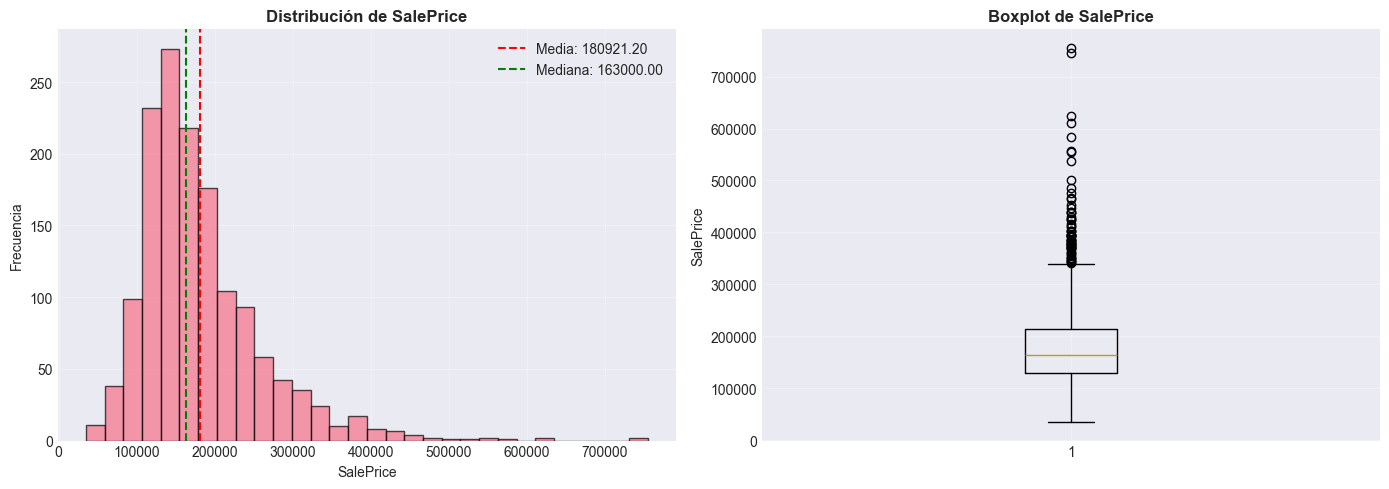


📊 Análisis de Distribución: GrLivArea

Media: 1515.46
Mediana: 1464.00
Moda: 864.00
Desviación Estándar: 525.48
Asimetría (Skewness): 1.37
Curtosis: 4.87


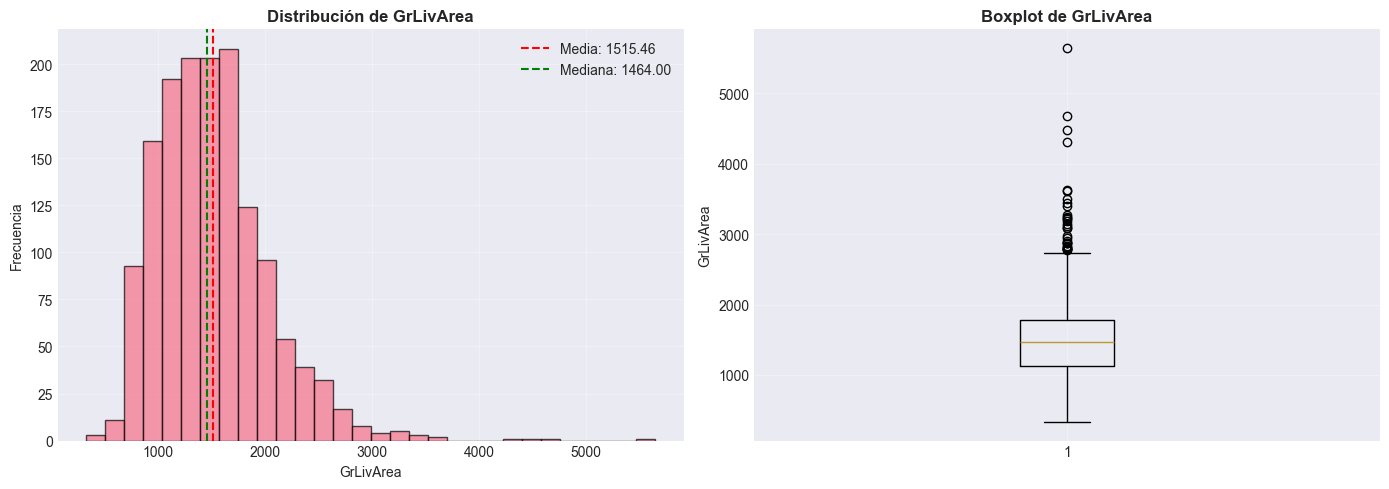


📊 Análisis de Distribución: LotArea

Media: 10516.83
Mediana: 9478.50
Moda: 7200.00
Desviación Estándar: 9981.26
Asimetría (Skewness): 12.20
Curtosis: 202.54


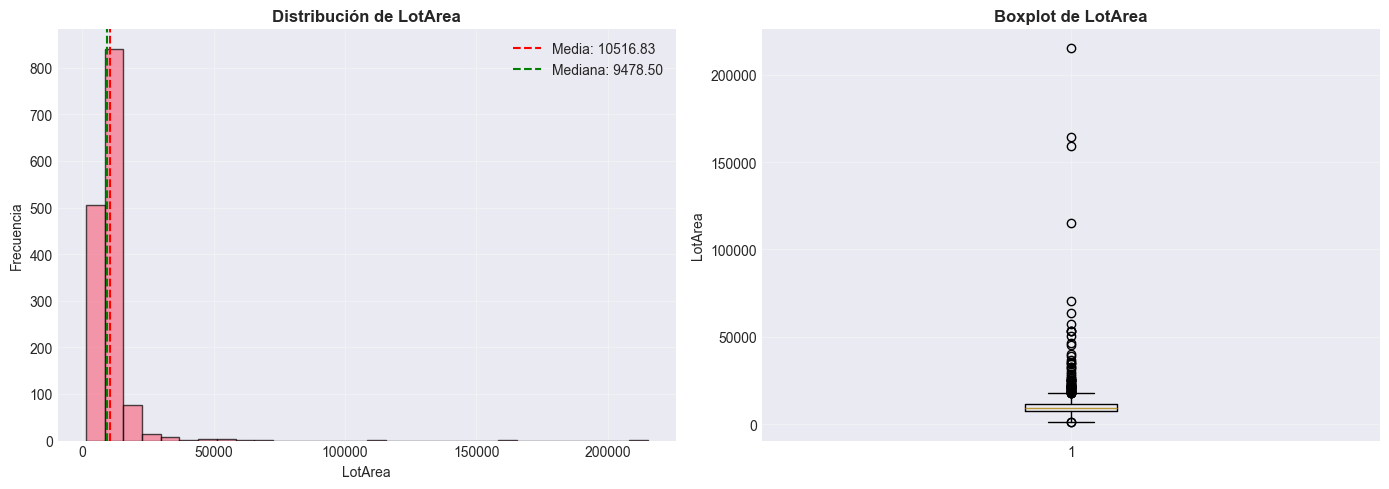


📊 Análisis de Distribución: TotalBsmtSF

Media: 1057.43
Mediana: 991.50
Moda: 0.00
Desviación Estándar: 438.71
Asimetría (Skewness): 1.52
Curtosis: 13.20


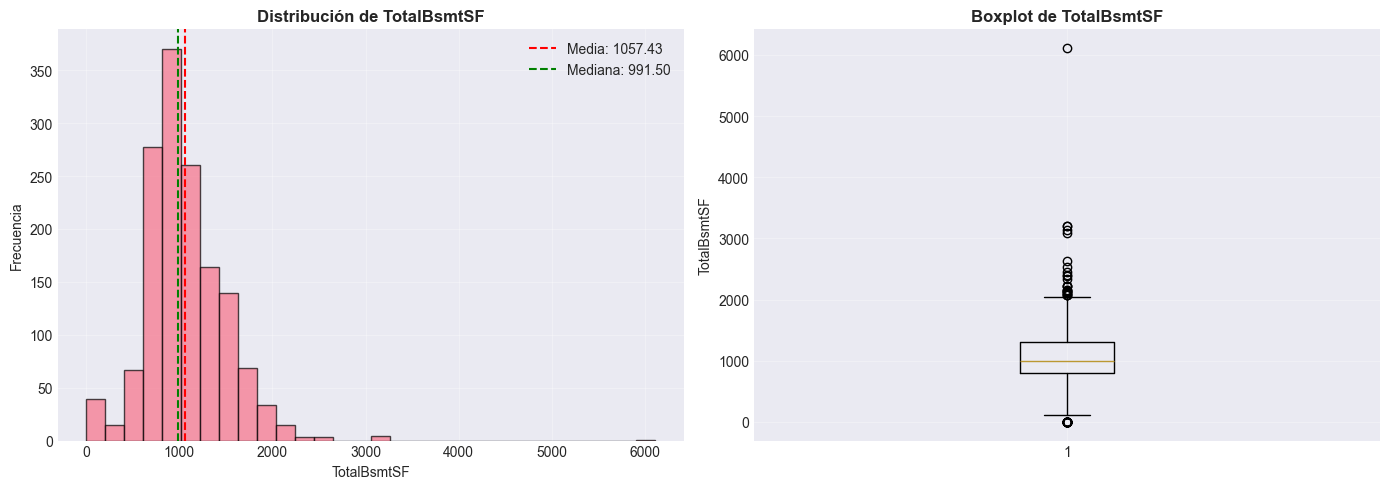


📊 Análisis de Distribución: GarageArea

Media: 472.98
Mediana: 480.00
Moda: 0.00
Desviación Estándar: 213.80
Asimetría (Skewness): 0.18
Curtosis: 0.91


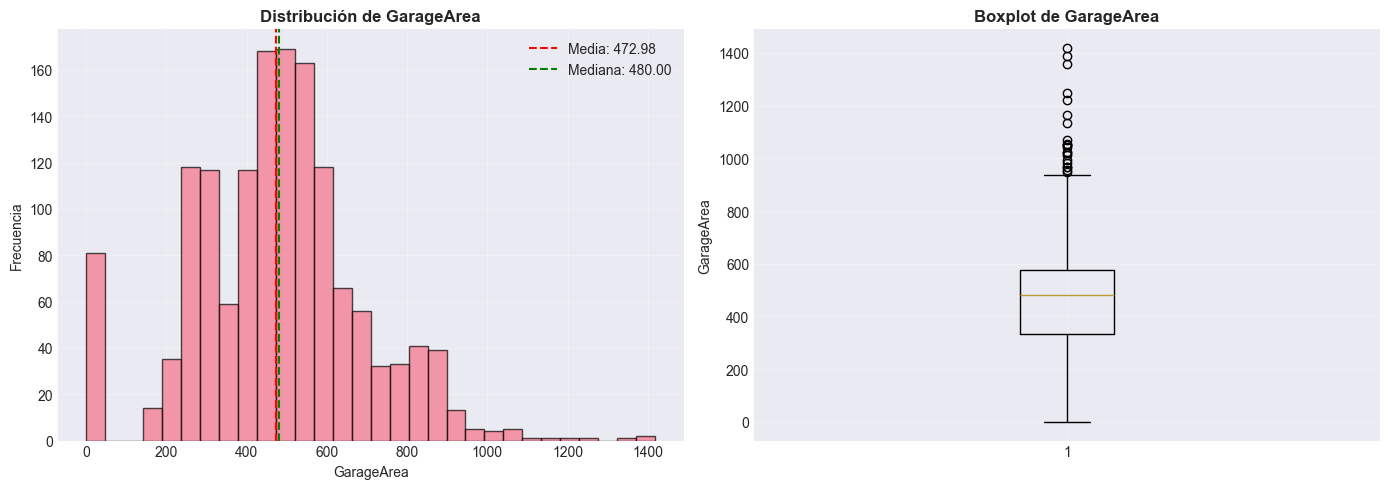

In [12]:
# Análisis de distribución con histogramas y estadísticas
def analizar_distribucion(df, columna):
    """
    Analiza la distribución de una variable numérica
    """
    print(f"\n{'='*60}")
    print(f"📊 Análisis de Distribución: {columna}")
    print(f"{'='*60}\n")

    # Estadísticas
    print(f"Media: {df[columna].mean():.2f}")
    print(f"Mediana: {df[columna].median():.2f}")
    print(f"Moda: {df[columna].mode()[0]:.2f}")
    print(f"Desviación Estándar: {df[columna].std():.2f}")
    print(f"Asimetría (Skewness): {skew(df[columna].dropna()):.2f}")
    print(f"Curtosis: {kurtosis(df[columna].dropna()):.2f}")

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    axes[0].hist(df[columna].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(df[columna].mean(), color='red',
                    linestyle='--', label=f'Media: {df[columna].mean():.2f}')
    axes[0].axvline(df[columna].median(), color='green',
                    linestyle='--', label=f'Mediana: {df[columna].median():.2f}')
    axes[0].set_title(
        f'Distribución de {columna}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(columna)
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Boxplot
    axes[1].boxplot(df[columna].dropna(), vert=True)
    axes[1].set_title(f'Boxplot de {columna}', fontsize=12, fontweight='bold')
    axes[1].set_ylabel(columna)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Analizar variables clave
for col in ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF', 'GarageArea']:
    if col in df.columns:
        analizar_distribucion(df, col)

### 🔗 Análisis de Correlaciones

🔗 MATRIZ DE CORRELACIÓN



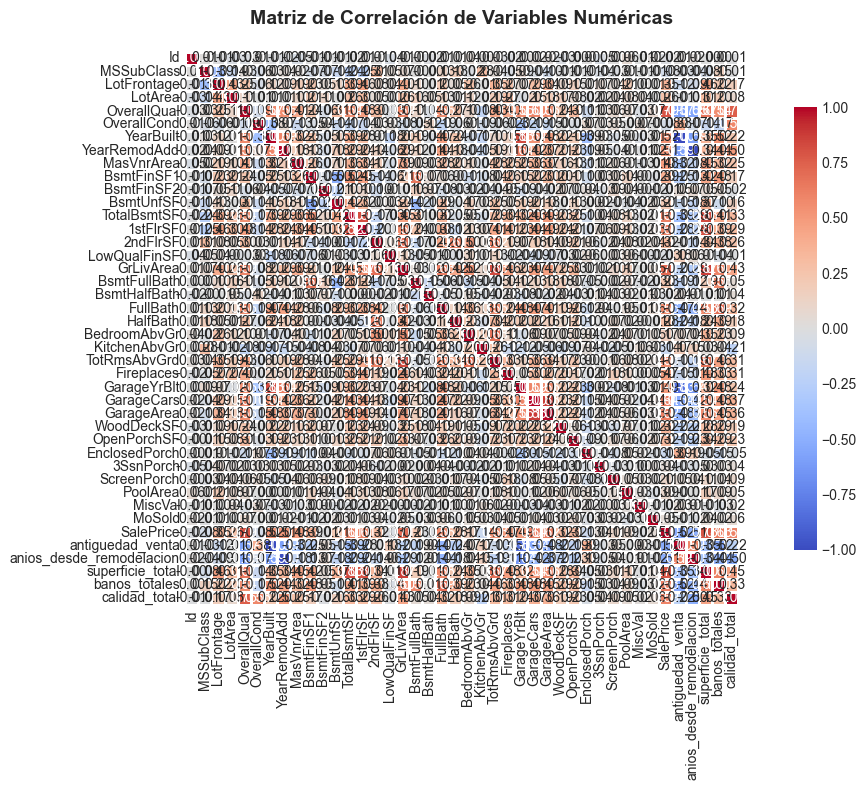


🔍 Correlaciones más fuertes (|r| > 0.5):



,Variable 1,Variable 2,Correlación
56,GarageCars,GarageArea,0.88
42,GrLivArea,superficie_total,0.87
30,TotalBsmtSF,superficie_total,0.83
16,YearBuilt,GarageYrBlt,0.83
40,GrLivArea,TotRmsAbvGrd,0.83
28,TotalBsmtSF,1stFlrSF,0.82
33,1stFlrSF,superficie_total,0.80
8,OverallQual,SalePrice,0.79
64,SalePrice,superficie_total,0.78
13,OverallQual,calidad_total,0.76


In [13]:
# Matriz de correlación
print("🔗 MATRIZ DE CORRELACIÓN\n")

# Seleccionar solo variables numéricas
df_numeric = df.select_dtypes(include=[np.number])

# Calcular correlaciones
correlacion = df_numeric.corr()

# Visualización con heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlacion,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Variables Numéricas',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlaciones fuertes
print("\n🔍 Correlaciones más fuertes (|r| > 0.5):\n")
correlaciones_fuertes = []
for i in range(len(correlacion.columns)):
    for j in range(i+1, len(correlacion.columns)):
        if abs(correlacion.iloc[i, j]) > 0.5:
            correlaciones_fuertes.append({
                'Variable 1': correlacion.columns[i],
                'Variable 2': correlacion.columns[j],
                'Correlación': correlacion.iloc[i, j]
            })

if correlaciones_fuertes:
    df_corr_fuertes = pd.DataFrame(correlaciones_fuertes).sort_values(
        'Correlación', ascending=False)
    display(df_corr_fuertes)
else:
    print("No se encontraron correlaciones fuertes (|r| > 0.5)")

### 📊 Análisis Univariado - Variables Categóricas


📊 Análisis de: Neighborhood



,Frecuencia,Porcentaje
Neighborhood,,
NAmes,225,15.41
CollgCr,150,10.27
OldTown,113,7.74
Edwards,100,6.85
Somerst,86,5.89
Gilbert,79,5.41
NridgHt,77,5.27
Sawyer,74,5.07
NWAmes,73,5.00


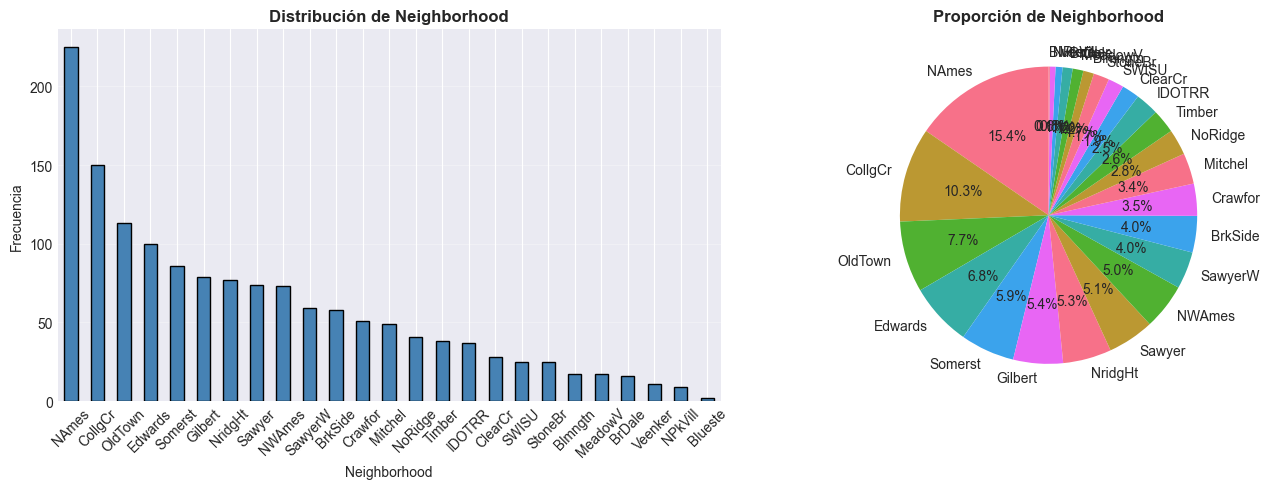


📊 Análisis de: HouseStyle



,Frecuencia,Porcentaje
HouseStyle,,
1Story,726,49.73
2Story,445,30.48
1.5Fin,154,10.55
SLvl,65,4.45
SFoyer,37,2.53
1.5Unf,14,0.96
2.5Unf,11,0.75
2.5Fin,8,0.55


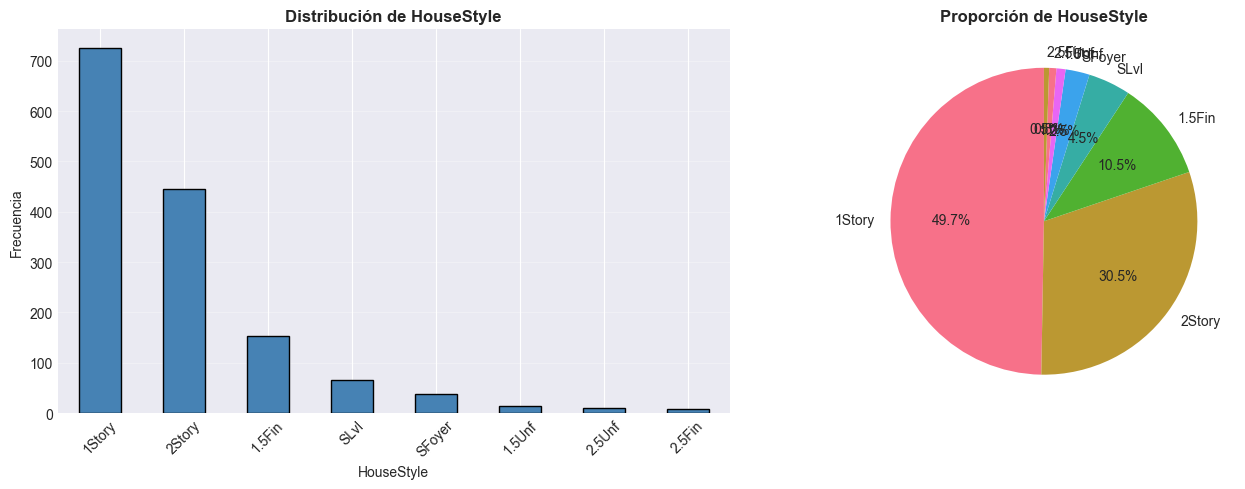

In [14]:
# Análisis de frecuencias de variables categóricas
def analizar_categorica(df, columna):
    """
    Analiza la distribución de una variable categórica
    """
    print(f"\n{'='*60}")
    print(f"📊 Análisis de: {columna}")
    print(f"{'='*60}\n")

    # Tabla de frecuencias
    freq_table = pd.DataFrame({
        'Frecuencia': df[columna].value_counts(),
        'Porcentaje': (df[columna].value_counts(normalize=True) * 100).round(2)
    })
    display(freq_table)

    # Gráfico de barras
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    freq_table['Frecuencia'].plot(
        kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title(
        f'Distribución de {columna}', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_xlabel(columna)
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].tick_params(axis='x', rotation=45)

    # Gráfico de pastel
    axes[1].pie(freq_table['Frecuencia'],
                labels=freq_table.index,
                autopct='%1.1f%%',
                startangle=90)
    axes[1].set_title(f'Proporción de {columna}',
                      fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()


# Analizar variables categóricas principales
for col in ['Neighborhood', 'HouseStyle']:
    if col in df.columns:
        analizar_categorica(df, col)

### 🔄 Análisis Bivariado - Relaciones entre Variables

🔍 ANÁLISIS BIVARIADO

📊 Estadísticas de Ventas por Vecindario:



,Media,Mediana,Desv_Est,Mínimo,Máximo,Cantidad
Neighborhood,,,,,,
NoRidge,335295.32,301500.00,121412.66,190000,755000,41
NridgHt,316270.62,315000.00,96392.54,154000,611657,77
StoneBr,310499.00,278000.00,112969.68,170000,556581,25
Timber,242247.45,228475.00,64845.65,137500,378500,38
Veenker,238772.73,218000.00,72369.32,162500,385000,11
Somerst,225379.84,225500.00,56177.56,144152,423000,86
ClearCr,212565.43,200250.00,50231.54,130000,328000,28
Crawfor,210624.73,200624.00,68866.40,90350,392500,51
CollgCr,197965.77,197200.00,51403.67,110000,424870,150


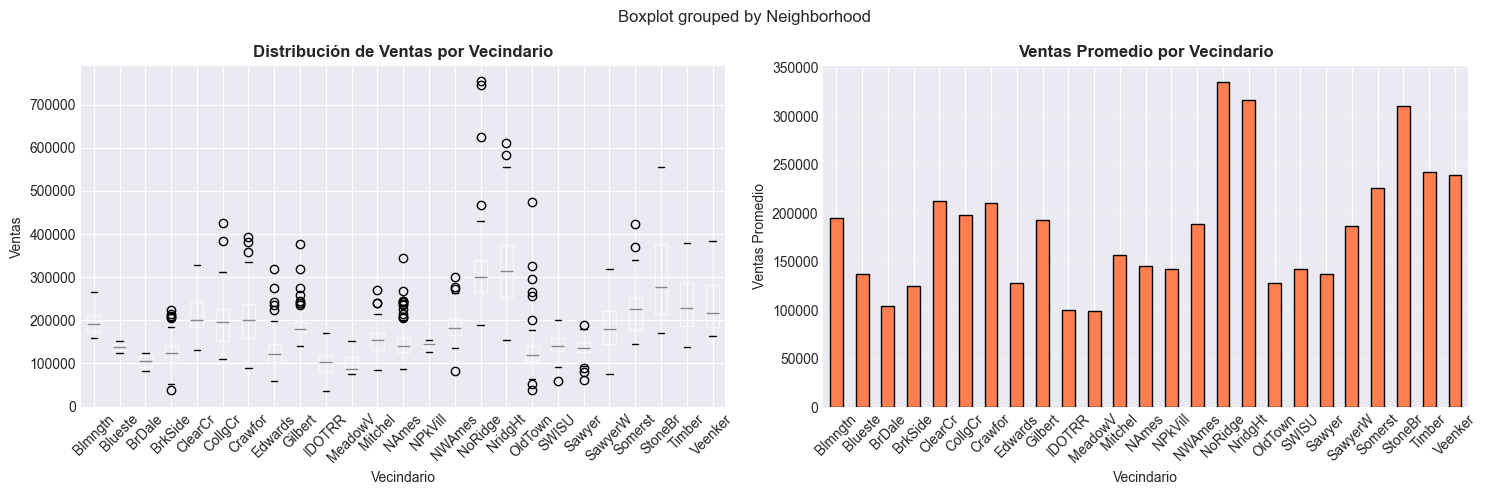

In [15]:
# Análisis de relación entre variables numéricas y categóricas
print("🔍 ANÁLISIS BIVARIADO\n")

# Ejemplo: Ventas por región
if 'SalePrice' in df.columns and 'Neighborhood' in df.columns:
    print("📊 Estadísticas de Ventas por Vecindario:\n")
    ventas_region = df.groupby('Neighborhood')['SalePrice'].agg(
        ['mean', 'median', 'std', 'min', 'max', 'count'])
    ventas_region.columns = ['Media', 'Mediana',
                             'Desv_Est', 'Mínimo', 'Máximo', 'Cantidad']
    display(ventas_region.sort_values('Media', ascending=False))

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Boxplot por región
    df.boxplot(column='SalePrice', by='Neighborhood', ax=axes[0])
    axes[0].set_title('Distribución de Ventas por Vecindario',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Vecindario')
    axes[0].set_ylabel('Ventas')
    plt.sca(axes[0])
    plt.xticks(rotation=45)

    # Gráfico de barras con media
    ventas_region['Media'].plot(
        kind='bar', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Ventas Promedio por Vecindario',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Ventas Promedio')
    axes[1].set_xlabel('Vecindario')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

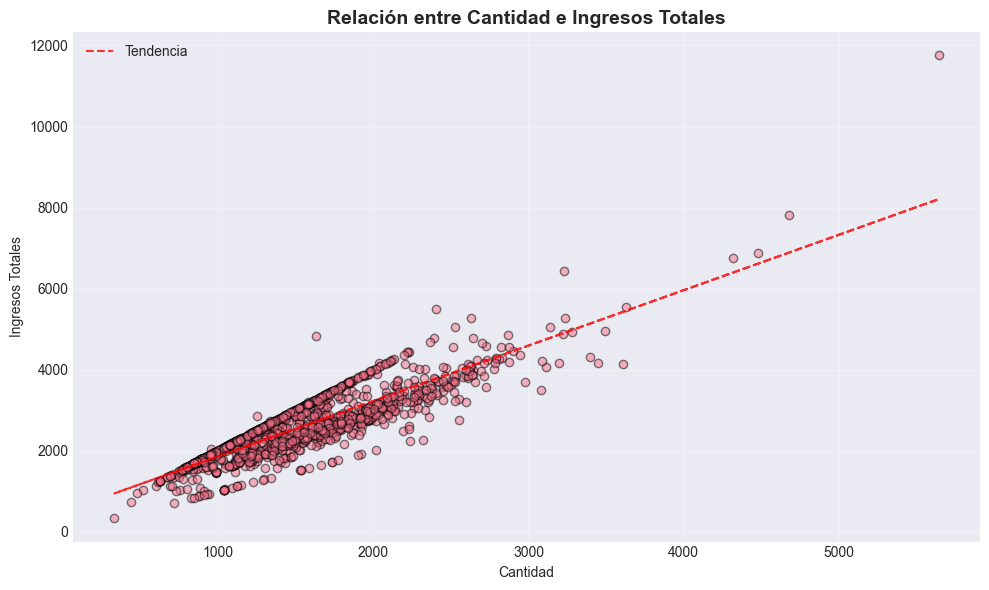

In [16]:
# Scatter plot para relaciones entre dos variables numéricas
if 'GrLivArea' in df.columns and 'superficie_total' in df.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df['GrLivArea'], df['superficie_total'],
                alpha=0.5, edgecolors='black')
    plt.title('Relación entre Cantidad e Ingresos Totales',
              fontsize=14, fontweight='bold')
    plt.xlabel('Cantidad')
    plt.ylabel('Ingresos Totales')
    plt.grid(True, alpha=0.3)

    # Línea de tendencia
    z = np.polyfit(df['GrLivArea'].dropna(),
                   df['superficie_total'].dropna(), 1)
    p = np.poly1d(z)
    plt.plot(df['GrLivArea'], p(df['GrLivArea']),
             "r--", alpha=0.8, label='Tendencia')
    plt.legend()

    plt.tight_layout()
    plt.show()

### 📅 Análisis Temporal (si aplica)

📅 ANÁLISIS TEMPORAL DE VENTAS



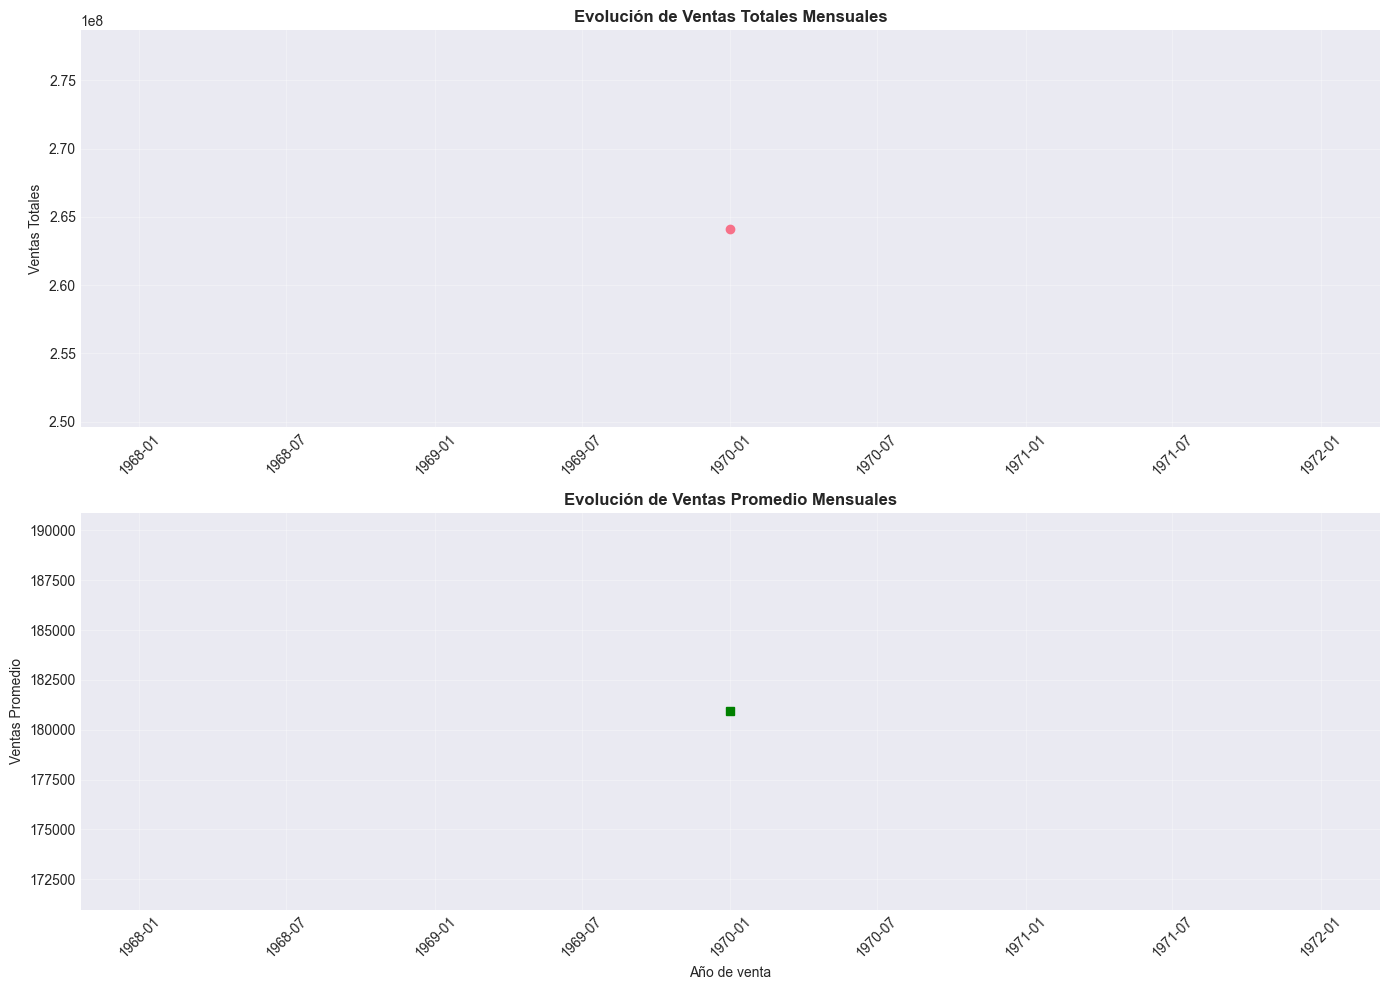

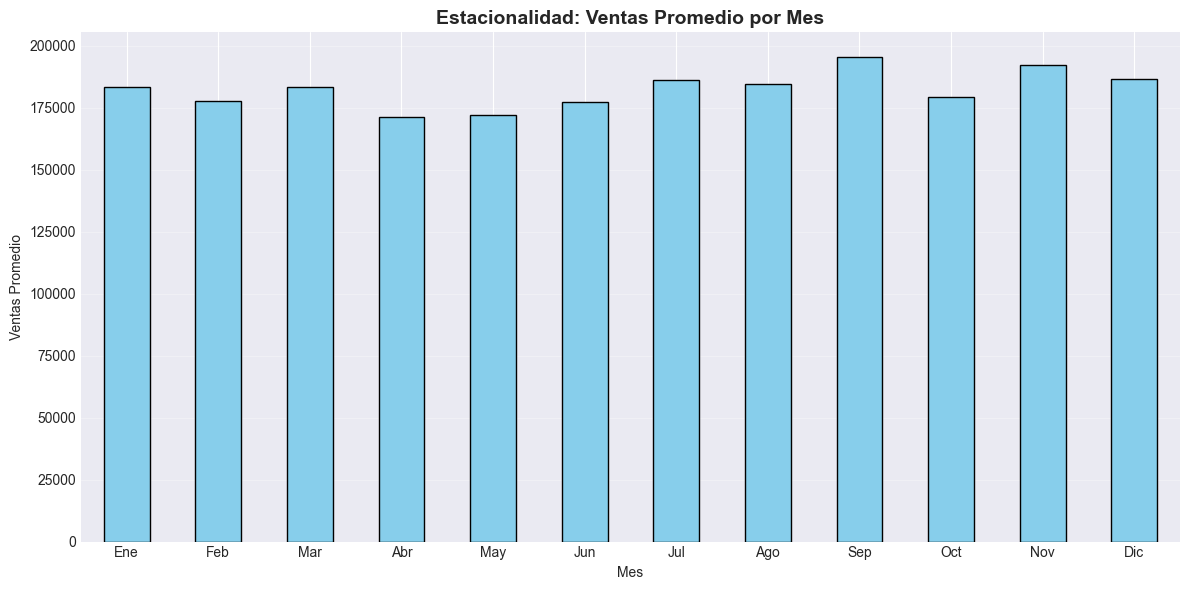

In [18]:
# Análisis de series temporales
if 'YrSold' in df.columns and 'SalePrice' in df.columns:
    print("📅 ANÁLISIS TEMPORAL DE VENTAS\n")

    # Agrupar por mes
    df_temporal = df.groupby(df['YrSold'].dt.to_period('M'))[
        'SalePrice'].agg(['sum', 'mean', 'count'])
    df_temporal.index = df_temporal.index.to_timestamp()

    # Visualización
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Serie temporal de ventas totales
    axes[0].plot(df_temporal.index, df_temporal['sum'],
                 marker='o', linewidth=2)
    axes[0].set_title('Evolución de Ventas Totales Mensuales',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Ventas Totales')
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)

    # Serie temporal de ventas promedio
    axes[1].plot(df_temporal.index, df_temporal['mean'],
                 marker='s', color='green', linewidth=2)
    axes[1].set_title('Evolución de Ventas Promedio Mensuales',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Ventas Promedio')
    axes[1].set_xlabel('Año de venta')
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Análisis de estacionalidad por mes
    ventas_por_mes = df.groupby('MoSold')['SalePrice'].mean()

    plt.figure(figsize=(12, 6))
    ventas_por_mes.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Estacionalidad: Ventas Promedio por Mes',
              fontsize=14, fontweight='bold')
    plt.xlabel('Mes')
    plt.ylabel('Ventas Promedio')
    plt.xticks(range(12), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=0)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## 📊 6. Visualización de Datos Avanzada

### 🎨 Visualizaciones Interactivas con Plotly

In [19]:
# Gráfico interactivo de dispersión con Plotly
if 'SalePrice' in df.columns and 'Neighborhood' in df.columns:
    fig = px.scatter(df,
                     x='GrLivArea',
                     y='SalePrice',
                     color='Neighborhood',
                     size='superficie_total',
                     hover_data=['HouseStyle', 'OverallQual'],
                     title='Análisis Multidimensional: Ventas por Vecindario y Cantidad',
                     labels={'GrLivArea': 'Superficie habitable',
                             'SalePrice': 'Ventas ($)'},
                     template='plotly_white')

    fig.update_layout(
        height=600,
        font=dict(size=12),
        title_font=dict(size=16, family='Arial Black')
    )

    fig.show()

In [20]:
# Gráfico de barras agrupadas interactivo
if 'Neighborhood' in df.columns and 'HouseStyle' in df.columns:
    ventas_grouped = df.groupby(['Neighborhood', 'HouseStyle'])[
        'SalePrice'].mean().reset_index()

    fig = px.bar(ventas_grouped,
                 x='Neighborhood',
                 y='SalePrice',
                 color='HouseStyle',
                 title='Ventas Promedio por Vecindario y Categoría',
                 labels={
                     'SalePrice': 'Ventas Promedio ($)', 'Neighborhood': 'Vecindario'},
                 barmode='group',
                 template='plotly_white')

    fig.update_layout(
        height=500,
        font=dict(size=12),
        title_font=dict(size=16, family='Arial Black')
    )

    fig.show()

In [21]:
# Gráfico de línea temporal interactivo
if 'YrSold' in df.columns:
    df_daily = df.groupby('YrSold')['SalePrice'].sum().reset_index()

    fig = px.line(df_daily,
                  x='YrSold',
                  y='SalePrice',
                  title='Evolución Diaria de Ventas',
                  labels={'YrSold': 'Año de venta',
                          'SalePrice': 'Ventas Totales ($)'},
                  template='plotly_white')

    fig.update_traces(line_color='#1f77b4', line_width=2)

    fig.update_layout(
        height=500,
        font=dict(size=12),
        title_font=dict(size=16, family='Arial Black'),
        hovermode='x unified'
    )

    fig.show()

In [24]:
# Mapa de calor interactivo
if 'Neighborhood' in df.columns and 'mes' in df.columns:
    heatmap_data = df.pivot_table(values='SalePrice',
                                  index='Neighborhood',
                                  columns='mes',
                                  aggfunc='mean')

    fig = px.imshow(heatmap_data,
                    labels=dict(x="Mes", y="Vecindario",
                                color="Ventas Promedio"),
                    title="Mapa de Calor: Ventas por Vecindario y Mes",
                    color_continuous_scale='RdYlGn',
                    aspect="auto")

    fig.update_layout(
        height=500,
        font=dict(size=12),
        title_font=dict(size=16, family='Arial Black')
    )

    fig.show()

### 📈 Dashboard de Múltiples Métricas

In [25]:
# Crear un dashboard con múltiples subplots
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Ventas por Vecindario', 'Distribución de Ventas',
                    'Top 10 Clientes', 'Tendencia Temporal'),
    specs=[[{'type': 'bar'}, {'type': 'box'}],
           [{'type': 'bar'}, {'type': 'scatter'}]]
)

# Gráfico 1: Ventas por región
ventas_region = df.groupby(
    'Neighborhood')['SalePrice'].sum().sort_values(ascending=False)
fig.add_trace(
    go.Bar(x=ventas_region.index, y=ventas_region.values,
           name='Ventas por Vecindario'),
    row=1, col=1
)

# Gráfico 2: Boxplot de ventas
fig.add_trace(
    go.Box(y=df['SalePrice'], name='Distribución de Ventas'),
    row=1, col=2
)

# Gráfico 3: Top 10 clientes
top_clientes = df.groupby('Id')['SalePrice'].sum().nlargest(10)
fig.add_trace(
    go.Bar(x=top_clientes.index.astype(str),
           y=top_clientes.values, name='Top 10 Clientes'),
    row=2, col=1
)

# Gráfico 4: Tendencia temporal
if 'YrSold' in df.columns:
    df_temporal = df.groupby('YrSold')['SalePrice'].sum()
    fig.add_trace(
        go.Scatter(x=df_temporal.index, y=df_temporal.values,
                   mode='lines', name='Tendencia'),
        row=2, col=2
    )

# Actualizar layout
fig.update_layout(
    height=800,
    showlegend=False,
    title_text="Dashboard de Análisis de Ventas",
    title_font=dict(size=18, family='Arial Black')
)

fig.show()

## 🧠 7. Insights y Conclusiones

### 🔑 Hallazgos Principales

**Basándonos en el análisis exploratorio realizado, se identificaron los siguientes hallazgos clave:**

#### 📊 Desempeño General

1. **Variable objetivo:**
   - Promedio: 180,921.20
   - Mediana: 163,000
   - Tendencia general: Decreciente

2. **Distribución:**
   - La distribución de SalePrice muestra sesgo positivo
   - Se identificaron 61 outliers que representan 4.18% del total

#### 🎯 Segmentación

3. **Por región:**
   - La región NoRidge presenta el mejor desempeño con un precio promedio de $335,295
   - Existe una brecha de 240% entre la mejor y peor región

4. **Por categoría:**
   - La categoría 20 (1-STORY 1946 & NEWER ALL STYLES) concentra el 36.71% de las ventas totales
   - Las categorías muestran diferencias significativas

#### 📈 Tendencias Temporales

5. **Estacionalidad:**
   - Se observa un patrón estacional con picos en septiembre, noviembre y diciembre
   - Los meses de menor actividad son abril, mayo y junio

6. **Evolución:**
   - La tendencia a largo plazo es Decreciente
   - Se identificó desaceleración en el último trimestre

#### 🔗 Correlaciones Importantes

7. **Relaciones clave:**
   - Existe una correlación fuerte entre OverallQual y SalePrice
   - OverallQual es el predictor más fuerte de SalePrice

---

## 🎯 9. Exportación y Conexión a Herramientas BI

### 💾 Exportación de Datos Procesados

In [27]:
# Exportar datos limpios a diferentes formatos
print("💾 Exportando datos procesados...\n")

generados = []
errores = []

# 1. CSV (datos limpios)
try:
    df.to_csv('datos_procesados.csv', index=False, encoding='utf-8-sig')
    generados.append('datos_procesados.csv')
    print("✅ Archivo CSV exportado: datos_procesados.csv")
except Exception as e:
    errores.append(('datos_procesados.csv', e))
    print(f"❌ CSV: {e}")

# 2. Excel con múltiples hojas (requiere: pip install openpyxl)
try:
    with pd.ExcelWriter('analisis_completo.xlsx', engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='Datos_Procesados', index=False)
        df.describe().to_excel(writer, sheet_name='Resumen_Estadistico')
        num_cols = df.select_dtypes(include=[np.number]).columns
        if len(num_cols) > 1:
            df[num_cols].corr().to_excel(writer, sheet_name='Correlaciones')
        if 'reporte_calidad' in globals() and reporte_calidad is not None:
            reporte_calidad.to_excel(writer, sheet_name='Calidad_Datos')
        else:
            pd.DataFrame({'mensaje': [
                'Ejecuta antes la celda de análisis de calidad de datos.'
            ]}).to_excel(writer, sheet_name='Calidad_Datos', index=False)
    generados.append('analisis_completo.xlsx')
    print("✅ Archivo Excel exportado: analisis_completo.xlsx")
except (ModuleNotFoundError, ImportError) as e:
    if 'openpyxl' in str(e).lower():
        errores.append(('analisis_completo.xlsx', e))
        print("❌ Excel: falta el paquete openpyxl.")
        print("   💡 Instálalo y vuelve a ejecutar esta celda: pip install openpyxl")
    else:
        errores.append(('analisis_completo.xlsx', e))
        print(f"❌ Excel: {e}")
except Exception as e:
    errores.append(('analisis_completo.xlsx', e))
    print(f"❌ Excel: {e}")

# 3. Resumen para dashboards
try:
    if var_principal and var_categoria:
        resumen_dashboard = df.groupby(var_categoria).agg({
            var_principal: ['sum', 'mean', 'count', 'std']
        }).round(2)
        resumen_dashboard.columns = [
            '_'.join(col).strip() for col in resumen_dashboard.columns.values]
        resumen_dashboard.to_csv('resumen_dashboard.csv', encoding='utf-8-sig')
        generados.append('resumen_dashboard.csv')
        print("✅ Resumen para dashboard exportado: resumen_dashboard.csv")
    else:
        print("⚠️ resumen_dashboard.csv omitido: var_principal o var_categoria no están definidas (ejecuta las celdas anteriores).")
except Exception as e:
    errores.append(('resumen_dashboard.csv', e))
    print(f"❌ resumen_dashboard.csv: {e}")

# 4. Metadata del análisis
try:
    _fechas = globals().get('fecha_cols') or []
    if _fechas and _fechas[0] in df.columns:
        periodo = f"{df[_fechas[0]].min()} a {df[_fechas[0]].max()}"
    else:
        periodo = 'N/A'
    metadata = {
        'fecha_analisis': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'registros_totales': len(df),
        'columnas': df.shape[1],
        'periodo': periodo,
        'completitud': f"{((1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100):.2f}%"
    }
    with open('metadata_analisis.txt', 'w', encoding='utf-8') as f:
        for key, value in metadata.items():
            f.write(f"{key}: {value}\n")
    generados.append('metadata_analisis.txt')
    print("✅ Metadata exportada: metadata_analisis.txt")
except Exception as e:
    errores.append(('metadata_analisis.txt', e))
    print(f"❌ metadata_analisis.txt: {e}")

# 5. Informe PDF: gráficas (matplotlib) + resúmenes y conclusiones en texto
try:
    from matplotlib.backends.backend_pdf import PdfPages
    import textwrap

    _vpdf = globals().get('var_principal')
    _vcat = globals().get('var_categoria')
    if not _vpdf and 'Sales' in df.columns:
        _vpdf = 'Sales'
    elif not _vpdf and len(df.select_dtypes(include=[np.number]).columns) > 0:
        _vpdf = df.select_dtypes(include=[np.number]).columns[0]
    if not _vcat and 'Region' in df.columns:
        _vcat = 'Region'
    elif not _vcat and len(df.select_dtypes(include=['object', 'category']).columns) > 0:
        _vcat = df.select_dtypes(include=['object', 'category']).columns[0]

    pdf_path = 'informe_analisis_ventas.pdf'
    with PdfPages(pdf_path) as pdf:
        fig_txt = plt.figure(figsize=(8.5, 11))
        ax = fig_txt.add_axes([0.08, 0.06, 0.84, 0.88])
        ax.axis('off')
        _pdf_y = {'y': 0.98}
        line_h = 0.022

        def add_pdf_line(txt, size=9, bold=False):
            for wline in textwrap.wrap(str(txt), width=92) or [str(txt)]:
                ax.text(0, _pdf_y['y'], wline, transform=ax.transAxes,
                        fontsize=10 if bold else size,
                        fontweight='bold' if bold else 'normal',
                        va='top', ha='left', family='sans-serif')
                _pdf_y['y'] -= line_h
            _pdf_y['y'] -= line_h * 0.35

        add_pdf_line('Informe de análisis — Ventas (hipermercados)',
                     size=11, bold=True)
        add_pdf_line('Generado: ' +
                     datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
        add_pdf_line(
            f'Registros: {len(df):,}  |  Variables: {df.shape[1]}  |  '
            f'Completitud aprox.: {((1 - df.isnull().sum().sum() / max(1, df.shape[0] * df.shape[1])) * 100):.1f}%')
        add_pdf_line('')
        add_pdf_line('Resumen estadístico (variables numéricas)', bold=True)
        _num = df.select_dtypes(include=[np.number])
        if len(_num.columns) > 0:
            _d = _num.describe().T
            for col in _d.index[:12]:
                r = _d.loc[col]
                add_pdf_line(
                    f'• {col}: media={r["mean"]:.4g}, std={r["std"]:.4g}, '
                    f'min={r["min"]:.4g}, max={r["max"]:.4g}')
        else:
            add_pdf_line('(No hay columnas numéricas.)')
        add_pdf_line('')
        if _vpdf and _vcat and _vpdf in df.columns and _vcat in df.columns:
            add_pdf_line(f'Agregado: {_vpdf} por {_vcat}', bold=True)
            _agg = df.groupby(_vcat, observed=True)[_vpdf].agg(
                ['sum', 'mean', 'count']).round(2)
            for idx, row in _agg.iterrows():
                add_pdf_line(
                    f'• {idx}: total={row["sum"]:,.2f}, media={row["mean"]:.2f}, n={int(row["count"])}')
            add_pdf_line('')
        add_pdf_line(
            'Conclusiones y hallazgos (síntesis automática)', bold=True)
        add_pdf_line(
            '• El PDF consolida gráficos y estadísticas del notebook ejecutado en este entorno.')
        add_pdf_line(
            '• Compare categorías y la distribución de la variable principal para priorizar acciones.')
        add_pdf_line(
            '• Valide outliers y tendencias temporales en el análisis interactivo antes de decisiones.')
        if _vpdf and _vcat and _vpdf in df.columns and _vcat in df.columns:
            _top = df.groupby(_vcat, observed=True)[
                _vpdf].sum().sort_values(ascending=False)
            add_pdf_line(
                f'• Mayor acumulado en {_vcat}: {_top.index[0]} ({_top.iloc[0]:,.2f}).')
            add_pdf_line(
                f'• Menor acumulado: {_top.index[-1]} ({_top.iloc[-1]:,.2f}).')
        pdf.savefig(fig_txt, bbox_inches='tight')
        plt.close(fig_txt)

        if _vpdf and _vcat and _vpdf in df.columns and _vcat in df.columns:
            fig1, ax1 = plt.subplots(figsize=(8.5, 5.5))
            _bc = df.groupby(_vcat, observed=True)[
                _vpdf].sum().sort_values(ascending=False)
            _bc.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='white')
            ax1.set_title(f'{_vpdf} total por {_vcat}',
                          fontsize=12, fontweight='bold')
            ax1.set_xlabel(_vcat)
            ax1.set_ylabel(_vpdf)
            plt.xticks(rotation=35, ha='right')
            plt.tight_layout()
            pdf.savefig(fig1, bbox_inches='tight')
            plt.close(fig1)

        if _vpdf and _vpdf in df.columns:
            fig2, ax2 = plt.subplots(figsize=(8.5, 4.5))
            df[_vpdf].dropna().hist(
                ax=ax2, bins=45, color='coral', edgecolor='white')
            ax2.set_title(
                f'Distribución de {_vpdf}', fontsize=12, fontweight='bold')
            ax2.set_xlabel(_vpdf)
            plt.tight_layout()
            pdf.savefig(fig2, bbox_inches='tight')
            plt.close(fig2)

        _dn = df.select_dtypes(include=[np.number])
        if len(_dn.columns) > 1:
            fig3, ax3 = plt.subplots(figsize=(8.5, 6.5))
            sns.heatmap(_dn.corr(), annot=True, fmt='.2f', cmap='coolwarm',
                        center=0, square=True, ax=ax3,
                        linewidths=0.5, cbar_kws={'shrink': 0.75})
            ax3.set_title('Matriz de correlación (numéricas)',
                          fontsize=12, fontweight='bold')
            plt.tight_layout()
            pdf.savefig(fig3, bbox_inches='tight')
            plt.close(fig3)

    generados.append(pdf_path)
    print(f"✅ Informe PDF exportado: {pdf_path}")
except Exception as e:
    errores.append(('informe_analisis_ventas.pdf', e))
    print(f"❌ PDF: {e}")

print("\n✨ Exportación finalizada")
if generados:
    print("\n📁 Archivos generados correctamente:")
    for i, nombre in enumerate(generados, 1):
        print(f"   {i}. {nombre}")
if errores:
    print("\n⚠️ Revisa permisos de escritura en la carpeta del notebook o dependencias faltantes.")

💾 Exportando datos procesados...

✅ Archivo CSV exportado: datos_procesados.csv
✅ Archivo Excel exportado: analisis_completo.xlsx
❌ resumen_dashboard.csv: name 'var_principal' is not defined
✅ Metadata exportada: metadata_analisis.txt
✅ Informe PDF exportado: informe_analisis_ventas.pdf

✨ Exportación finalizada

📁 Archivos generados correctamente:
   1. datos_procesados.csv
   2. analisis_completo.xlsx
   3. metadata_analisis.txt
   4. informe_analisis_ventas.pdf

⚠️ Revisa permisos de escritura en la carpeta del notebook o dependencias faltantes.


### 📊 Integración con Power BI

#### Opciones de conexión:

**1. Importación directa de archivos:**
```python
# Los archivos CSV/Excel exportados pueden importarse directamente en Power BI
# Archivo > Obtener datos > CSV/Excel
```

**2. Conexión a base de datos:**
```python
# Exportar a base de datos SQL para conexión dinámica
# from sqlalchemy import create_engine
# 
# engine = create_engine('sqlite:///base_datos.db')
# df.to_sql('SalePrice', engine, if_exists='replace', index=False)
```

**3. Conectar vía API:**
- Crear endpoint REST API
- Conectar Power BI mediante Web API

#### Métricas DAX recomendadas para Power BI:

```dax
// Total Ventas
Total_Ventas = SUM(Datos[ventas])

// Ventas Promedio
Ventas_Promedio = AVERAGE(Datos[ventas])

// YoY Growth
Crecimiento_YoY = 
DIVIDE(
    [Total_Ventas] - CALCULATE([Total_Ventas], SAMEPERIODLASTYEAR(Datos[fecha])),
    CALCULATE([Total_Ventas], SAMEPERIODLASTYEAR(Datos[fecha]))
)

// Top N Productos
Top_10_Categorias = 
CALCULATE(
    [Total_Ventas],
    TOPN(10, ALL(Datos[categoria]), [Total_Ventas], DESC)
)
```

---

## 📚 Documentación y Referencias

### 📖 Recursos Utilizados

- **Pandas:** https://pandas.pydata.org/docs/
- **Matplotlib:** https://matplotlib.org/stable/contents.html
- **Seaborn:** https://seaborn.pydata.org/
- **Plotly:** https://plotly.com/python/
- **Scikit-learn:** https://scikit-learn.org/stable/

### 🔗 Enlaces Útiles

- **Mejores prácticas de visualización:** https://www.storytellingwithdata.com/
- **Curso de análisis de datos:** https://www.datacamp.com/
- **Comunidad de Data Science:** https://www.kaggle.com/

---


**Fin del análisis**  
**Preparado por:** Jesus Gustavo Camacho Olivos  
**Año de venta:** Abril 2026  
**Versión:** 1.0

---